Text(0.5, 1.0, '3V Model with Etimeact=10ms')

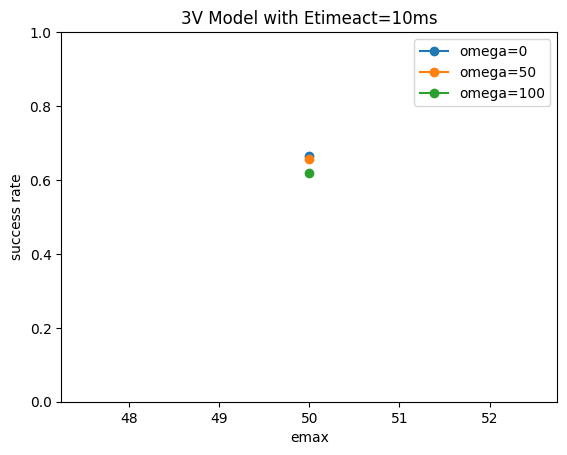

In [107]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

success_rate = defaultdict(lambda: defaultdict(float))
colors = ['#2b4fa2','#ed1c24','#007c40','#000001','#00babb','#a33694','#bcbe32']
data2 = {}
dt = 0.5

with open('FTE_results_new_emask.csv', 'r') as f:
    lines = f.readlines()
    
    for k in range(0, len(lines), 2):
        header = lines[k].strip()  # e.g., "IC1_mask1"
        
        # 1. Use Regex to extract the numbers from the header
        # This looks for digits (\d+) after 'IC' and 'mask'
        match = re.search(r'IC(\d+)_Emax(\d+)_omega(\d+)', header)
        
        if match:
            i_idx = int(match.group(1))
            j_idx = int(match.group(2))
            omega_idx = int(match.group(3))
            # 2. Parse the data2 line into a list of floats
            values = [float(x) if x else None for x in lines[k+1].strip().split(',')]
            
            # 3. Build the nested dictionary structure
            if i_idx not in data2:
                data2[i_idx] = {}
            if j_idx not in data2[i_idx]:
                data2[i_idx][j_idx] = {}
            if omega_idx not in data2[i_idx][j_idx]:
                data2[i_idx][j_idx][omega_idx] = []
            data2[i_idx][j_idx][omega_idx] = values

IC_n = 130           
for E_max in sorted(data2[0].keys()):
    for IC_idx in data2.keys():
        if IC_idx > IC_n:
            continue
        for omega_idx in data2[IC_idx][E_max].keys():
            if len(data2[IC_idx][E_max][omega_idx]) <= 250/dt:
                success_rate[E_max][omega_idx] += 1.0 / (    IC_n + 1      )            


for omega in data2[0][50].keys():
    plt.plot(sorted(success_rate.keys()), [success_rate[E_max][omega] for E_max in sorted(success_rate.keys())],'-o',label=f'omega={omega}')

plt.legend()
plt.xlabel('emax')
plt.ylabel('success rate')
plt.ylim(0,1)
plt.savefig('3V Model with Etimeact=10ms.png')
plt.title('3V Model with Etimeact=10ms')


Text(0.5, 1.0, '3V Model with Etimeact=100ms')

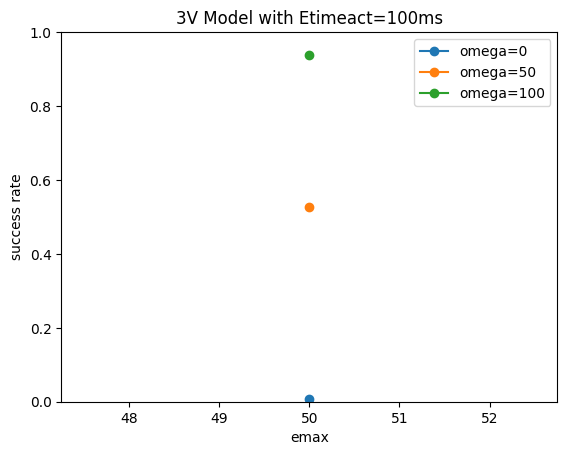

In [108]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

success_rate = defaultdict(lambda: defaultdict(float))
colors = ['#2b4fa2','#ed1c24','#007c40','#000001','#00babb','#a33694','#bcbe32']
data2 = {}
dt = 0.5

with open('FTE_results_new_emask_etimeact_100.csv', 'r') as f:
    lines = f.readlines()
    
    for k in range(0, len(lines), 2):
        header = lines[k].strip()  # e.g., "IC1_mask1"
        
        # 1. Use Regex to extract the numbers from the header
        # This looks for digits (\d+) after 'IC' and 'mask'
        match = re.search(r'IC(\d+)_Emax(\d+)_omega(\d+)', header)
        
        if match:
            i_idx = int(match.group(1))
            j_idx = int(match.group(2))
            omega_idx = int(match.group(3))
            # 2. Parse the data2 line into a list of floats
            values = [float(x) if x else None for x in lines[k+1].strip().split(',')]
            
            # 3. Build the nested dictionary structure
            if i_idx not in data2:
                data2[i_idx] = {}
            if j_idx not in data2[i_idx]:
                data2[i_idx][j_idx] = {}
            if omega_idx not in data2[i_idx][j_idx]:
                data2[i_idx][j_idx][omega_idx] = []
            data2[i_idx][j_idx][omega_idx] = values

IC_n = 130           
for E_max in sorted(data2[0].keys()):
    for IC_idx in data2.keys():
        if IC_idx > IC_n:
            continue
        for omega_idx in data2[IC_idx][E_max].keys():
            if len(data2[IC_idx][E_max][omega_idx]) <= 250/dt:
                success_rate[E_max][omega_idx] += 1.0 / (    IC_n + 1      )            


for omega in data2[0][50].keys():
    plt.plot(sorted(success_rate.keys()), [success_rate[E_max][omega] for E_max in sorted(success_rate.keys())],'-o',label=f'omega={omega}')

plt.legend()
plt.xlabel('emax')
plt.ylabel('success rate')
plt.ylim(0,1)
plt.savefig('3V Model with Etimeact=100ms.png')
plt.title('3V Model with Etimeact=100ms')


In [99]:
data2[0].keys()

dict_keys([50])

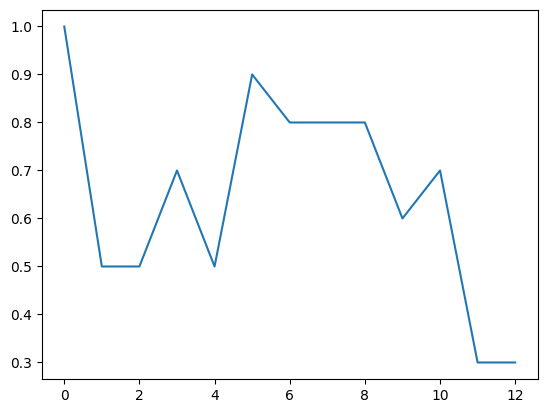

In [92]:
# print omega 50 success/fail rate on every 10 IC
Success_rate_omega50 = [0]*((IC_n -1)//10 +1)
for IC in range(0, IC_n -1):
    if len(data2[IC][50][50]) <= 250/dt:
        Success_rate_omega50[IC//10] += 1.0 / 10
plt.plot(Success_rate_omega50)
        

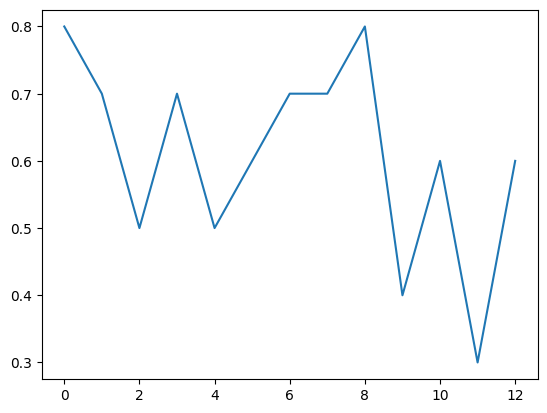

In [94]:
# print omega 50 success/fail rate on every 10 IC
Success_rate_omega0 = [0]*((IC_n -1)//10 +1)
for IC in range(0, IC_n -1):
    if len(data2[IC][50][100]) <= 250/dt:
        Success_rate_omega0[IC//10] += 1.0 / 10
plt.plot(Success_rate_omega0)